In [42]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

train = pd.read_csv("../data/raw/train.csv")
print(f"Shape: {train.shape}")
train.head(3)

Shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1000,1653.8500,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5000,3778.2000,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4000,5841.3500,No


In [43]:
train["churn"] = (train["Churn"] == "Yes").astype(int)
train["TotalCharges"] = pd.to_numeric(train["TotalCharges"], errors="coerce")
train.dropna(subset=["TotalCharges"], inplace=True)

replace_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]
for col in replace_cols:
    train[col] = train[col].replace({"No internet service": "No", "No phone service": "No"})

binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
yes_no_cols = replace_cols
multi_cols = ["InternetService", "Contract", "PaymentMethod"]
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

print(f"Target distribution:\n{train['churn'].value_counts(normalize=True).round(4)}")
print(f"\nRows after cleaning: {len(train):,}")
print(f"\nMultipleLines values:  {sorted(train['MultipleLines'].unique())}")
print(f"OnlineSecurity values: {sorted(train['OnlineSecurity'].unique())}")

Target distribution:
churn
0   0.7748
1   0.2252
Name: proportion, dtype: float64

Rows after cleaning: 594,194

MultipleLines values:  ['No', 'Yes']
OnlineSecurity values: ['No', 'Yes']


## Chi-square tests of independence

In [44]:
cat_cols = binary_cols + yes_no_cols + multi_cols + ["SeniorCitizen"]

chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(train[col], train["churn"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (len(train) * (min(ct.shape) - 1)))
    chi2_results.append({"feature": col, "chi2": chi2, "p_value": p, "dof": dof, "cramers_v": cramers_v})

chi2_df = (
    pd.DataFrame(chi2_results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)
chi2_df["significant"] = chi2_df["p_value"] < 0.05
chi2_df

,feature,chi2,p_value,dof,cramers_v,significant
0,PaymentMethod,134817.8266,0.0000,3,0.4763,True
1,Contract,132429.2518,0.0000,2,0.4721,True
2,InternetService,107801.9397,0.0000,2,0.4259,True
3,PaperlessBilling,48298.2229,0.0000,1,0.2851,True
4,Dependents,34329.5950,0.0000,1,0.2404,True
5,SeniorCitizen,33193.9833,0.0000,1,0.2364,True
6,Partner,30944.9821,0.0000,1,0.2282,True
7,OnlineSecurity,24859.0229,0.0000,1,0.2045,True
8,TechSupport,21678.1690,0.0000,1,0.1910,True
9,StreamingTV,8172.3500,0.0000,1,0.1173,True


## T-tests & point-biserial correlations (numeric features vs Churn)

In [45]:
ttest_results = []
for col in numeric_cols:
    group0 = train.loc[train["churn"] == 0, col]
    group1 = train.loc[train["churn"] == 1, col]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
    r_pb, r_p = stats.pointbiserialr(train["churn"], train[col])
    ttest_results.append({
        "feature": col,
        "mean_no_churn": group0.mean(),
        "mean_churn": group1.mean(),
        "t_stat": t_stat,
        "p_value": p_val,
        "point_biserial_r": r_pb,
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df

,feature,mean_no_churn,mean_churn,t_stat,p_value,point_biserial_r
0,tenure,42.2313,17.1253,415.5916,0.0000,-0.4185
1,MonthlyCharges,61.2936,81.5975,-284.2238,0.0000,0.2730
2,TotalCharges,2771.5005,1540.9760,202.5659,0.0000,-0.2184


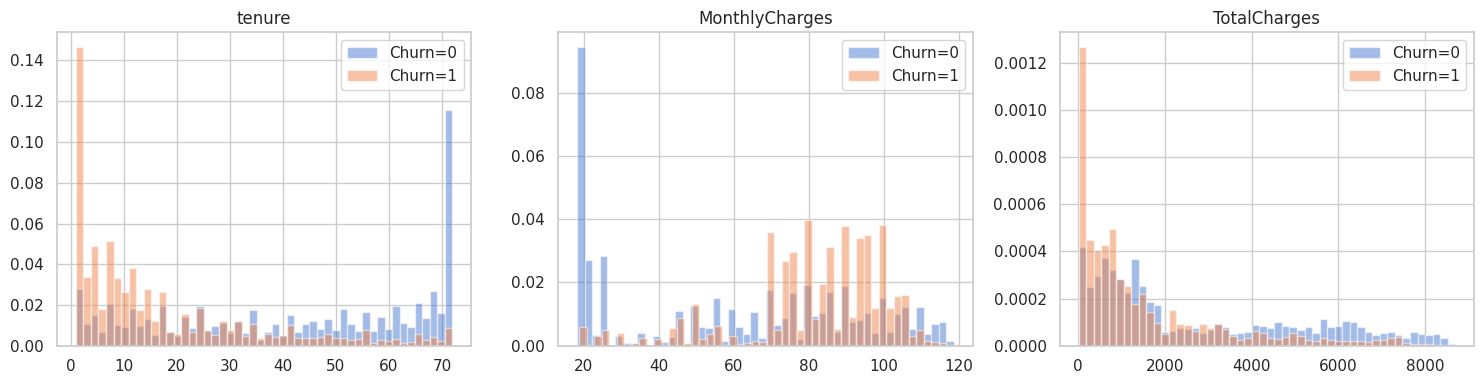

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    for label, grp in train.groupby("churn"):
        ax.hist(grp[col], bins=50, alpha=0.5, label=f"Churn={label}", density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## Feature Engineering

In [47]:
service_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]
train["num_services"] = train[service_cols].apply(lambda r: (r == "Yes").sum(), axis=1)

addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
train["num_addons"] = train[addon_cols].apply(lambda r: (r == "Yes").sum(), axis=1)

streaming_cols = ["StreamingTV", "StreamingMovies"]
train["num_streaming"] = train[streaming_cols].apply(lambda r: (r == "Yes").sum(), axis=1)

train["avg_charge_per_month"] = train["TotalCharges"] / train["tenure"].clip(lower=1)

train["charge_per_service"] = train["MonthlyCharges"] / train["num_services"].clip(lower=1)

train["tenure_bin"] = pd.cut(
    train["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6m", "7-12m", "13-24m", "25-48m", "49-72m"],
)

train["is_new_customer"] = (train["tenure"] <= 6).astype(int)

train["auto_pay"] = train["PaymentMethod"].isin([
    "Bank transfer (automatic)", "Credit card (automatic)"
]).astype(int)

train["log_tenure"] = np.log1p(train["tenure"])
train["log_total_charges"] = np.log1p(train["TotalCharges"])

new_features = [
    "num_services", "num_addons", "num_streaming",
    "avg_charge_per_month", "charge_per_service",
    "is_new_customer", "auto_pay", "log_tenure", "log_total_charges",
]

print("New features — descriptive stats:")
train[new_features].describe().round(2)

New features — descriptive stats:


,num_services,num_addons,num_streaming,avg_charge_per_month,charge_per_service,is_new_customer,auto_pay,log_tenure,log_total_charges
count,594194.0000,594194.0000,594194.0000,594194.0000,594194.0000,594194.0000,594194.0000,594194.0000,594194.0000
mean,3.4500,1.2400,0.8100,66.5600,22.7200,0.1500,0.4300,3.2400,7.1800
std,2.2100,1.3600,0.8900,39.9700,12.0900,0.3500,0.4900,1.0600,1.3500
min,0.0000,0.0000,0.0000,0.7500,3.4400,0.0000,0.0000,0.6900,2.9900
25%,1.0000,0.0000,0.0000,32.2500,15.6000,0.0000,0.0000,2.5600,6.4600
50%,3.0000,1.0000,0.0000,73.3700,19.8100,0.0000,0.0000,3.5800,7.2700
75%,5.0000,2.0000,2.0000,91.3900,24.4500,0.0000,1.0000,4.1400,8.3600
max,8.0000,4.0000,2.0000,1260.8000,93.7000,1.0000,1.0000,4.2900,9.0700


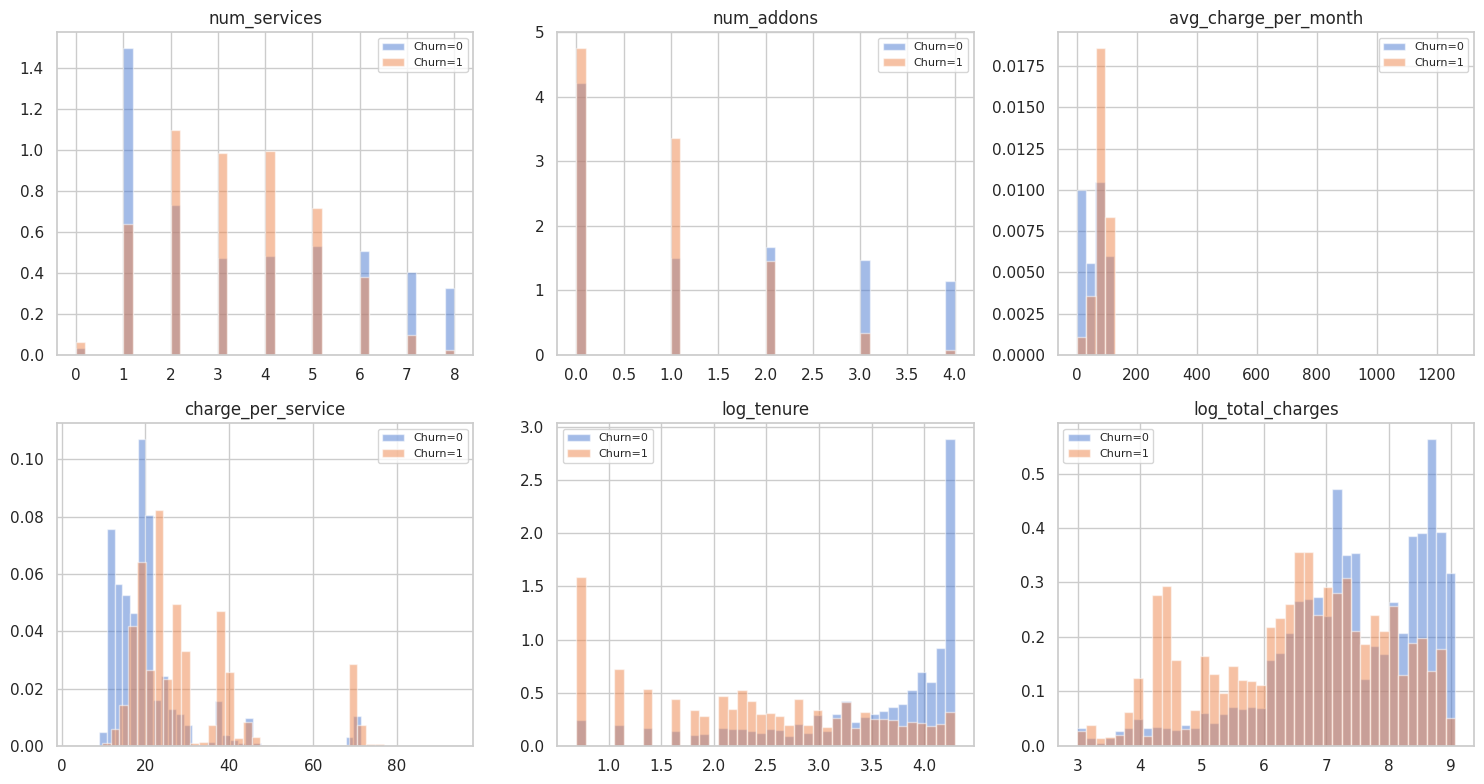

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_features = ["num_services", "num_addons", "avg_charge_per_month",
                 "charge_per_service", "log_tenure", "log_total_charges"]
for ax, feat in zip(axes.ravel(), plot_features):
    for label in [0, 1]:
        subset = train.loc[train["churn"] == label, feat]
        ax.hist(subset, bins=40, alpha=0.5, label=f"Churn={label}", density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [49]:
fe_ttest = []
for col in new_features:
    g0 = train.loc[train["churn"] == 0, col]
    g1 = train.loc[train["churn"] == 1, col]
    t, p = stats.ttest_ind(g0, g1, equal_var=False)
    r_pb, _ = stats.pointbiserialr(train["churn"], train[col])
    fe_ttest.append({
        "feature": col, "mean_no_churn": g0.mean(), "mean_churn": g1.mean(),
        "t_stat": t, "p_value": p, "point_biserial_r": r_pb,
    })
pd.DataFrame(fe_ttest)

,feature,mean_no_churn,mean_churn,t_stat,p_value,point_biserial_r
0,num_services,3.4976,3.3053,34.1288,0.0000,-0.0363
1,num_addons,1.3827,0.7608,194.3713,0.0000,-0.1915
2,num_streaming,0.7494,1.0219,-100.3078,0.0000,0.1274
3,avg_charge_per_month,61.4352,84.1904,-153.9125,0.0000,0.2378
4,charge_per_service,20.7184,29.6073,-213.4537,0.0000,0.3071
5,is_new_customer,0.0856,0.3508,-193.8133,0.0000,0.3143
6,auto_pay,0.5136,0.1392,312.2044,0.0000,-0.3160
7,log_tenure,3.4854,2.3785,341.9773,0.0000,-0.4379
8,log_total_charges,7.3590,6.5549,186.4616,0.0000,-0.2482


## Baseline Logistic Regression (original features only)

In [50]:
baseline_formula = (
    "churn ~ C(gender) + SeniorCitizen + C(Partner) + C(Dependents) + tenure"
    " + C(PhoneService) + C(MultipleLines) + C(InternetService)"
    " + C(OnlineSecurity) + C(OnlineBackup) + C(DeviceProtection)"
    " + C(TechSupport) + C(StreamingTV) + C(StreamingMovies)"
    " + C(Contract) + C(PaperlessBilling) + C(PaymentMethod)"
    " + MonthlyCharges + TotalCharges"
)

baseline_model = smf.logit(baseline_formula, data=train).fit(method="bfgs", maxiter=100, disp=0)
print(baseline_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594170
Method:                           MLE   Df Model:                           23
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.4145
Time:                        21:07:19   Log-Likelihood:            -1.8559e+05
converged:                      False   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                      -0.7907      0.051    -15.611      0.000      -0.890      -0.691
C(gender)[T.Male]               

## Enhanced Logistic Regression (with engineered features)

Replaces high-VIF raw features (`MonthlyCharges`, `TotalCharges`) with derived versions and adds
service counts, customer tenure segment, and payment behaviour indicators.

In [51]:
enhanced_formula = (
    "churn ~ C(gender) + SeniorCitizen + C(Partner) + C(Dependents)"
    " + C(InternetService) + C(Contract) + C(PaperlessBilling)"
    " + num_services + num_addons + num_streaming"
    " + log_tenure + avg_charge_per_month + charge_per_service"
    " + is_new_customer + auto_pay"
    " + log_tenure:avg_charge_per_month"
    " + is_new_customer:C(Contract)"
)

enhanced_model = smf.logit(enhanced_formula, data=train).fit(method="bfgs", maxiter=100, disp=0)
print(enhanced_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594173
Method:                           MLE   Df Model:                           20
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.4187
Time:                        21:07:53   Log-Likelihood:            -1.8426e+05
converged:                      False   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   0.7214      0.048     15.077      0.000       0.628       0.815
C(gender)[T.Male]                          -

## Model comparison

In [52]:
from sklearn.metrics import roc_auc_score

comparison = pd.DataFrame({
    "Baseline": {
        "Pseudo_R2": baseline_model.prsquared,
        "AIC": baseline_model.aic,
        "BIC": baseline_model.bic,
        "Log-Likelihood": baseline_model.llf,
        "Num_params": baseline_model.df_model + 1,
        "ROC-AUC": roc_auc_score(train["churn"], baseline_model.predict(train)),
    },
    "Enhanced": {
        "Pseudo_R2": enhanced_model.prsquared,
        "AIC": enhanced_model.aic,
        "BIC": enhanced_model.bic,
        "Log-Likelihood": enhanced_model.llf,
        "Num_params": enhanced_model.df_model + 1,
        "ROC-AUC": roc_auc_score(train["churn"], enhanced_model.predict(train)),
    },
})
comparison["Delta"] = comparison["Enhanced"] - comparison["Baseline"]

print("Baseline vs Enhanced model:\n")
comparison

Baseline vs Enhanced model:



,Baseline,Enhanced,Delta
Pseudo_R2,0.4145,0.4187,0.0042
AIC,371228.1184,368563.9773,-2664.1411
BIC,371499.1975,368801.1715,-2698.0260
Log-Likelihood,-185590.0592,-184260.9887,1329.0705
Num_params,24.0000,21.0000,-3.0000
ROC-AUC,0.9079,0.9087,0.0007


In [53]:
lr_stat = -2 * (baseline_model.llf - enhanced_model.llf)
lr_df = abs(enhanced_model.df_model - baseline_model.df_model)
lr_p = stats.chi2.sf(lr_stat, lr_df) if lr_stat > 0 else 1.0

print(f"Likelihood Ratio test (enhanced vs baseline):")
print(f"  LR statistic: {lr_stat:,.1f}")
print(f"  Δ df:          {lr_df}")
print(f"  p-value:       {lr_p:.2e}")
print(f"\n→ Enhanced model {'significantly' if lr_p < 0.05 else 'does NOT significantly'} "
      f"improve over the baseline.")

Likelihood Ratio test (enhanced vs baseline):
  LR statistic: 2,658.1
  Δ df:          3.0
  p-value:       0.00e+00

→ Enhanced model significantly improve over the baseline.


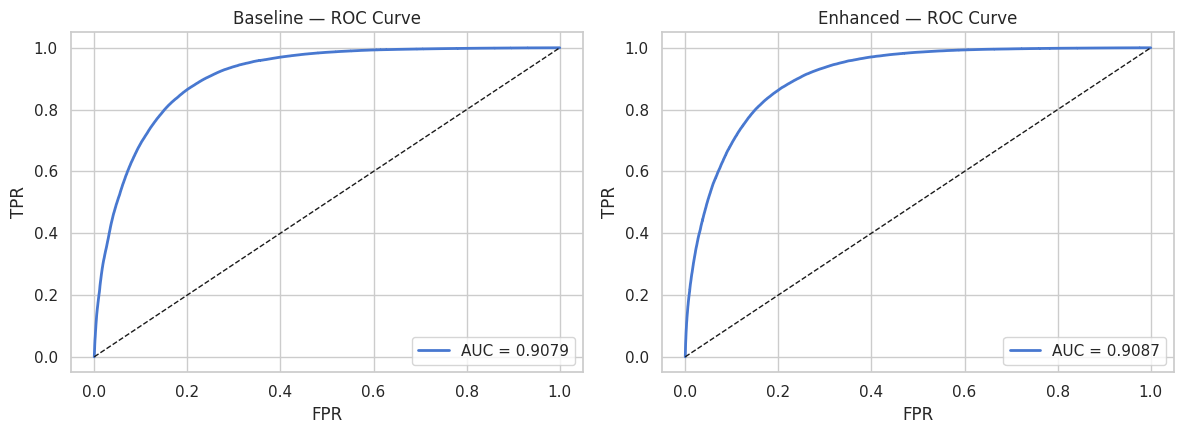

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, model) in zip(axes, [("Baseline", baseline_model), ("Enhanced", enhanced_model)]):
    from sklearn.metrics import roc_curve as _rc
    fpr, tpr, _ = _rc(train["churn"], model.predict(train))
    auc = roc_auc_score(train["churn"], model.predict(train))
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set(xlabel="FPR", ylabel="TPR", title=f"{name} — ROC Curve")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [55]:
logit_model = enhanced_model  # placeholder — overridden after Optuna tuning below

## Optuna Cross-Validated Model Tuning

Uses **Stratified K-Fold** cross-validation with **Optuna** to search over:
- Feature group selection (which blocks of features to include)
- Interaction terms to add or drop
- L1 / L2 / ElasticNet regularization strength
- Classification threshold

The search runs with sklearn's `LogisticRegression` for speed, then the best
configuration is refit in **statsmodels** for full statistical inference.

In [56]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import patsy

optuna.logging.set_verbosity(optuna.logging.WARNING)

candidate_formula = (
    "churn ~ C(gender) + SeniorCitizen + C(Partner) + C(Dependents)"
    " + C(InternetService) + C(Contract) + C(PaperlessBilling)"
    " + C(PaymentMethod)"
    " + num_services + num_addons + num_streaming"
    " + tenure + log_tenure + MonthlyCharges + TotalCharges"
    " + avg_charge_per_month + charge_per_service + log_total_charges"
    " + is_new_customer + auto_pay"
    " + log_tenure:avg_charge_per_month"
    " + is_new_customer:MonthlyCharges"
    " + tenure:MonthlyCharges"
    " + SeniorCitizen:MonthlyCharges"
    " + auto_pay:C(Contract)"
    " + num_services:C(InternetService)"
    " + SeniorCitizen:C(InternetService)"
    " + is_new_customer:C(Contract)"
    " + C(PaperlessBilling):C(Contract)"
)

y_cv, X_cv = patsy.dmatrices(candidate_formula, data=train, return_type="dataframe")
y_cv = y_cv.values.ravel()

feature_groups = {
    "demographics": [c for c in X_cv.columns if any(
        k in c for k in ["gender", "SeniorCitizen", "Partner", "Dependents"]
    ) and ":" not in c],
    "contract_billing": [c for c in X_cv.columns if any(
        k in c for k in ["Contract", "PaperlessBilling", "PaymentMethod"]
    ) and ":" not in c],
    "internet": [c for c in X_cv.columns if "InternetService" in c and ":" not in c],
    "service_counts": ["num_services", "num_addons", "num_streaming"],
    "tenure_raw": ["tenure"],
    "tenure_log": ["log_tenure"],
    "charges_raw": ["MonthlyCharges", "TotalCharges"],
    "charges_eng": ["avg_charge_per_month", "charge_per_service", "log_total_charges"],
    "binary_flags": ["is_new_customer", "auto_pay"],
    "interact_tenure_charge": [c for c in X_cv.columns if "log_tenure:avg_charge" in c],
    "interact_new_monthly": [c for c in X_cv.columns if "is_new_customer:Monthly" in c],
    "interact_tenure_monthly": [c for c in X_cv.columns if "tenure:Monthly" in c],
    "interact_senior_monthly": [c for c in X_cv.columns if "SeniorCitizen:Monthly" in c],
    "interact_autopay_contract": [c for c in X_cv.columns if "auto_pay:" in c],
    "interact_services_internet": [c for c in X_cv.columns if "num_services:" in c],
    "interact_senior_internet": [c for c in X_cv.columns if "SeniorCitizen:C(Internet" in c],
    "interact_new_contract": [c for c in X_cv.columns if "is_new_customer:C(Contract" in c],
    "interact_billing_contract": [c for c in X_cv.columns if "PaperlessBilling" in c and ":" in c],
}

for name, cols in feature_groups.items():
    print(f"  {name:35s} → {len(cols)} features")
print(f"\nTotal candidate features: {X_cv.shape[1]} (incl. Intercept)")
print(f"Feature groups: {len(feature_groups)}")

  demographics                        → 4 features
  contract_billing                    → 6 features
  internet                            → 2 features
  service_counts                      → 3 features
  tenure_raw                          → 1 features
  tenure_log                          → 1 features
  charges_raw                         → 2 features
  charges_eng                         → 3 features
  binary_flags                        → 2 features
  interact_tenure_charge              → 1 features
  interact_new_monthly                → 1 features
  interact_tenure_monthly             → 1 features
  interact_senior_monthly             → 1 features
  interact_autopay_contract           → 2 features
  interact_services_internet          → 2 features
  interact_senior_internet            → 2 features
  interact_new_contract               → 2 features
  interact_billing_contract           → 2 features

Total candidate features: 39 (incl. Intercept)
Feature groups: 18


In [57]:
ALWAYS_ON = ["contract_billing", "internet"]
OPTIONAL  = [k for k in feature_groups if k not in ALWAYS_ON]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    selected_cols = ["Intercept"]
    for grp in ALWAYS_ON:
        selected_cols.extend(feature_groups[grp])
    for grp in OPTIONAL:
        if trial.suggest_categorical(f"use_{grp}", [True, False]):
            selected_cols.extend(feature_groups[grp])

    selected_cols = [c for c in selected_cols if c in X_cv.columns]
    if len(selected_cols) < 3:
        return 0.5

    X_sel = X_cv[selected_cols]

    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    C = trial.suggest_float("C", 1e-3, 100.0, log=True)
    solver_map = {"l1": "saga", "l2": "lbfgs", "elasticnet": "saga"}
    solver = solver_map[penalty]

    params = dict(
        penalty=penalty, C=C, solver=solver,
        max_iter=500, random_state=42, n_jobs=-1,
    )
    if penalty == "elasticnet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.1, 0.9)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(**params)),
    ])

    scores = cross_val_score(pipe, X_sel, y_cv, cv=skf, scoring="roc_auc", n_jobs=-1)

    trial.set_user_attr("cv_mean", scores.mean())
    trial.set_user_attr("cv_std", scores.std())
    trial.set_user_attr("n_features", X_sel.shape[1])
    trial.set_user_attr("selected_groups",
        ALWAYS_ON + [g for g in OPTIONAL if trial.params.get(f"use_{g}", False)]
    )

    return scores.mean()

print("Objective function defined — ready to optimise.")

Objective function defined — ready to optimise.


In [58]:
%%time
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    study_name="churn_logit_cv",
)
study.optimize(objective, n_trials=80, show_progress_bar=True)

best = study.best_trial
print(f"\n{'='*60}")
print(f"Best trial #{best.number}")
print(f"  CV ROC-AUC:  {best.value:.5f} ± {best.user_attrs['cv_std']:.5f}")
print(f"  Features:    {best.user_attrs['n_features']}")
print(f"  C:           {best.params['C']:.4f}")
print(f"  Penalty:     {best.params['penalty']}")
if "l1_ratio" in best.params:
    print(f"  L1 ratio:    {best.params['l1_ratio']:.3f}")
print(f"  Groups:      {best.user_attrs['selected_groups']}")
print(f"{'='*60}")

Best trial: 78. Best value: 0.911477: 100%|██████████| 80/80 [3:16:15<00:00, 147.19s/it]   


Best trial #78
  CV ROC-AUC:  0.91148 ± 0.00100
  Features:    33
  C:           3.0454
  Penalty:     l2
  Groups:      ['contract_billing', 'internet', 'demographics', 'service_counts', 'tenure_raw', 'tenure_log', 'charges_raw', 'binary_flags', 'interact_new_monthly', 'interact_tenure_monthly', 'interact_senior_monthly', 'interact_autopay_contract', 'interact_services_internet', 'interact_new_contract', 'interact_billing_contract']
CPU times: user 37.2 s, sys: 21.2 s, total: 58.4 s
Wall time: 3h 16min 15s


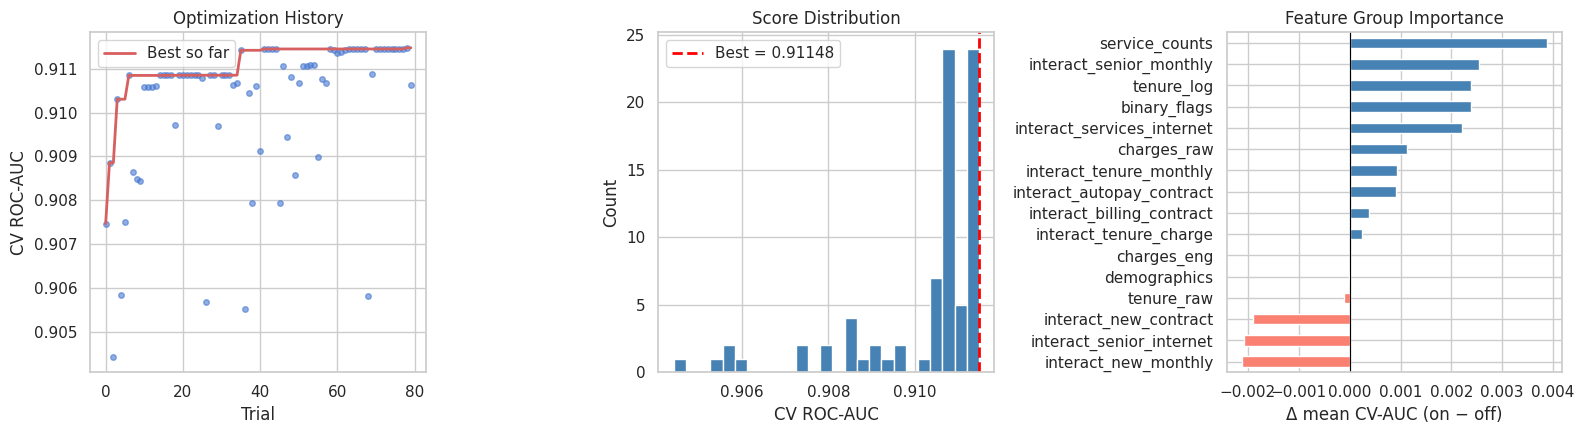

In [59]:
trials_df = study.trials_dataframe().sort_values("value", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(trials_df["number"], trials_df["value"], "o", ms=4, alpha=0.6)
best_so_far = trials_df.sort_values("number")["value"].cummax()
axes[0].plot(trials_df.sort_values("number")["number"], best_so_far, "r-", lw=2, label="Best so far")
axes[0].set(xlabel="Trial", ylabel="CV ROC-AUC", title="Optimization History")
axes[0].legend()

axes[1].hist(trials_df["value"], bins=25, color="steelblue", edgecolor="white")
axes[1].axvline(best.value, color="red", ls="--", lw=2, label=f"Best = {best.value:.5f}")
axes[1].set(xlabel="CV ROC-AUC", ylabel="Count", title="Score Distribution")
axes[1].legend()

group_importance = {}
for g in OPTIONAL:
    key = f"params_use_{g}"
    if key in trials_df.columns:
        on = trials_df.loc[trials_df[key] == True, "value"]
        off = trials_df.loc[trials_df[key] == False, "value"]
        if len(on) > 0 and len(off) > 0:
            group_importance[g] = on.mean() - off.mean()

gi = pd.Series(group_importance).sort_values()
gi.plot.barh(ax=axes[2], color=["salmon" if v < 0 else "steelblue" for v in gi])
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set(xlabel="Δ mean CV-AUC (on − off)", title="Feature Group Importance")

plt.tight_layout()
plt.show()

In [60]:
print("Top 10 trials:\n")
top10 = trials_df.head(10)[["number", "value", "user_attrs_cv_std", "user_attrs_n_features", "params_C", "params_penalty"]].copy()
top10.columns = ["trial", "cv_auc", "cv_std", "n_feats", "C", "penalty"]
top10

Top 10 trials:



,trial,cv_auc,cv_std,n_feats,C,penalty
78,78,0.9115,0.0010,33,3.0454,l2
77,77,0.9115,0.0010,32,0.7506,l2
42,42,0.9115,0.0010,28,0.0880,l1
41,41,0.9115,0.0010,28,0.0859,l1
70,70,0.9114,0.0010,30,0.3696,l2
74,74,0.9114,0.0010,30,0.4233,l2
73,73,0.9114,0.0010,30,0.3613,l2
71,71,0.9114,0.0010,30,0.1671,l2
76,76,0.9114,0.0010,30,0.7656,l2
64,64,0.9114,0.0010,30,0.1541,l2


## Refit best Optuna config in statsmodels

In [61]:
best_groups = best.user_attrs["selected_groups"]
best_cols = ["Intercept"]
for grp in best_groups:
    best_cols.extend(feature_groups[grp])
best_cols = [c for c in best_cols if c in X_cv.columns]

X_best = X_cv[best_cols]

tuned_model = sm.Logit(y_cv, X_best).fit(method="bfgs", maxiter=200, disp=0)
print(tuned_model.summary())
print(f"\nSelected {len(best_cols)} features from groups: {best_groups}")

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594162
Method:                           MLE   Df Model:                           31
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                  0.4273
Time:                        00:26:00   Log-Likelihood:            -1.8153e+05
converged:                      False   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                              1.2553     55.344      0.023      0.982    -107.218     109.728
C(Contract)

## Three-model comparison (Baseline → Enhanced → Tuned)

In [62]:
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

tuned_probs = tuned_model.predict(X_best)
tuned_auc = roc_auc_score(y_cv, tuned_probs)

skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
cv_aucs = []
for tr_idx, val_idx in skf_final.split(X_best, y_cv):
    fold_model = sm.Logit(y_cv[tr_idx], X_best.iloc[tr_idx]).fit(method="bfgs", maxiter=200, disp=0)
    fold_probs = fold_model.predict(X_best.iloc[val_idx])
    cv_aucs.append(roc_auc_score(y_cv[val_idx], fold_probs))
cv_aucs = np.array(cv_aucs)

final_comparison = pd.DataFrame({
    "Baseline": {
        "Pseudo_R2": baseline_model.prsquared,
        "AIC": baseline_model.aic,
        "BIC": baseline_model.bic,
        "Train ROC-AUC": roc_auc_score(train["churn"], baseline_model.predict(train)),
        "CV ROC-AUC (mean)": np.nan,
        "CV ROC-AUC (std)": np.nan,
        "Num params": baseline_model.df_model + 1,
    },
    "Enhanced": {
        "Pseudo_R2": enhanced_model.prsquared,
        "AIC": enhanced_model.aic,
        "BIC": enhanced_model.bic,
        "Train ROC-AUC": roc_auc_score(train["churn"], enhanced_model.predict(train)),
        "CV ROC-AUC (mean)": np.nan,
        "CV ROC-AUC (std)": np.nan,
        "Num params": enhanced_model.df_model + 1,
    },
    "Tuned (Optuna)": {
        "Pseudo_R2": tuned_model.prsquared,
        "AIC": tuned_model.aic,
        "BIC": tuned_model.bic,
        "Train ROC-AUC": tuned_auc,
        "CV ROC-AUC (mean)": cv_aucs.mean(),
        "CV ROC-AUC (std)": cv_aucs.std(),
        "Num params": len(best_cols),
    },
})

print(f"Tuned model — 5-Fold CV ROC-AUC: {cv_aucs.mean():.5f} ± {cv_aucs.std():.5f}")
print(f"Per-fold: {[f'{a:.5f}' for a in cv_aucs]}\n")
final_comparison

Tuned model — 5-Fold CV ROC-AUC: 0.91148 ± 0.00050
Per-fold: ['0.91208', '0.91077', '0.91136', '0.91201', '0.91116']



,Baseline,Enhanced,Tuned (Optuna)
Pseudo_R2,0.4145,0.4187,0.4273
AIC,371228.1184,368563.9773,363133.7037
BIC,371499.1975,368801.1715,363495.1425
Train ROC-AUC,0.9079,0.9087,0.9115
CV ROC-AUC (mean),NaN,NaN,0.9115
CV ROC-AUC (std),NaN,NaN,0.0005
Num params,24.0000,21.0000,33.0000


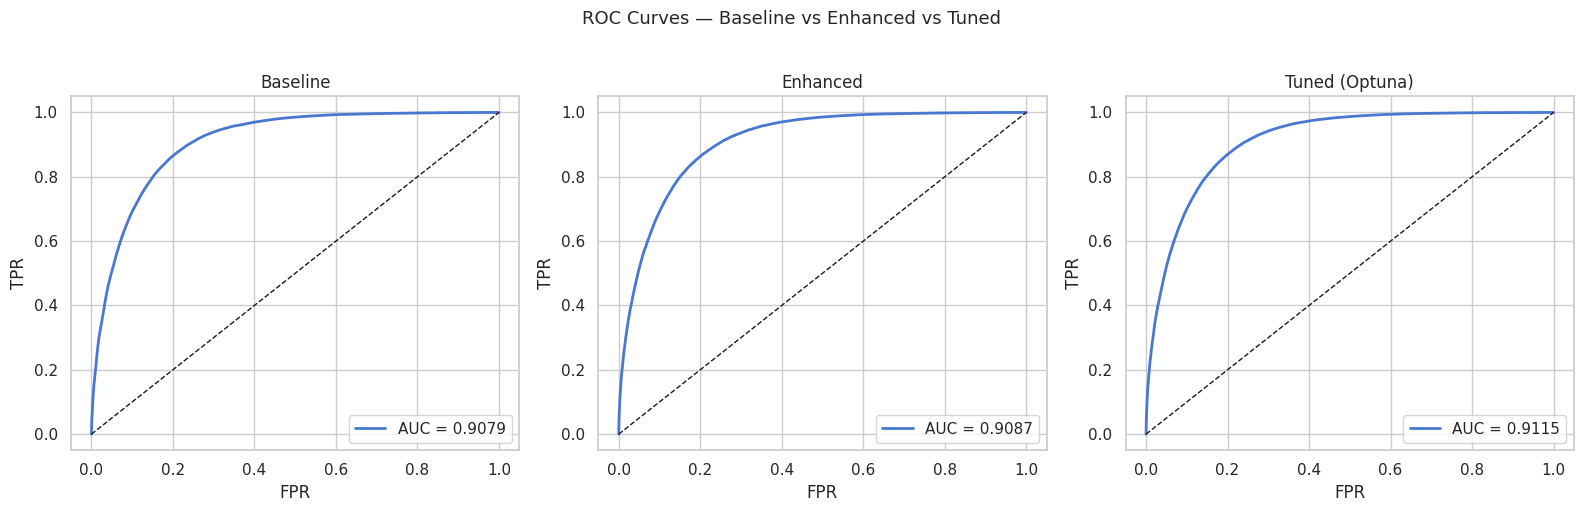

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [
    ("Baseline", train["churn"].values, baseline_model.predict(train)),
    ("Enhanced", train["churn"].values, enhanced_model.predict(train)),
    ("Tuned (Optuna)", y_cv, tuned_probs),
]

for ax, (name, yt, yp) in zip(axes, models):
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set(xlabel="FPR", ylabel="TPR", title=f"{name}")
    ax.legend(loc="lower right")

plt.suptitle("ROC Curves — Baseline vs Enhanced vs Tuned", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [64]:
logit_model = tuned_model
print("logit_model now points to the Optuna-tuned model for all downstream analysis.")

logit_model now points to the Optuna-tuned model for all downstream analysis.


## Odds ratios & 95% confidence intervals

In [65]:
odds_ratios = pd.DataFrame({
    "OR": np.exp(logit_model.params),
    "CI_lower": np.exp(logit_model.conf_int()[0]),
    "CI_upper": np.exp(logit_model.conf_int()[1]),
    "p_value": logit_model.pvalues,
})
odds_ratios = odds_ratios.drop("Intercept", errors="ignore")
odds_ratios["significant"] = odds_ratios["p_value"] < 0.05

print("Significant predictors (sorted by OR):\n")
odds_ratios[odds_ratios["significant"]].sort_values("OR", ascending=False)

Significant predictors (sorted by OR):



,OR,CI_lower,CI_upper,p_value,significant
C(InternetService)[T.Fiber optic],2.5415,2.3302,2.7719,0.0000,True
num_services:C(InternetService)[T.No],2.5362,2.2658,2.8390,0.0000,True
SeniorCitizen,1.7456,1.5820,1.9261,0.0000,True
C(PaperlessBilling)[T.Yes],1.5434,1.5064,1.5813,0.0000,True
C(PaperlessBilling)[T.Yes]:C(Contract)[T.Two year],1.3336,1.1828,1.5037,0.0000,True
num_services:C(InternetService)[T.Fiber optic],1.2957,1.2771,1.3146,0.0000,True
num_streaming,1.2728,1.2466,1.2996,0.0000,True
num_services,1.2680,1.2317,1.3054,0.0000,True
tenure,1.0331,1.0299,1.0362,0.0000,True
is_new_customer:MonthlyCharges,1.0068,1.0057,1.0080,0.0000,True


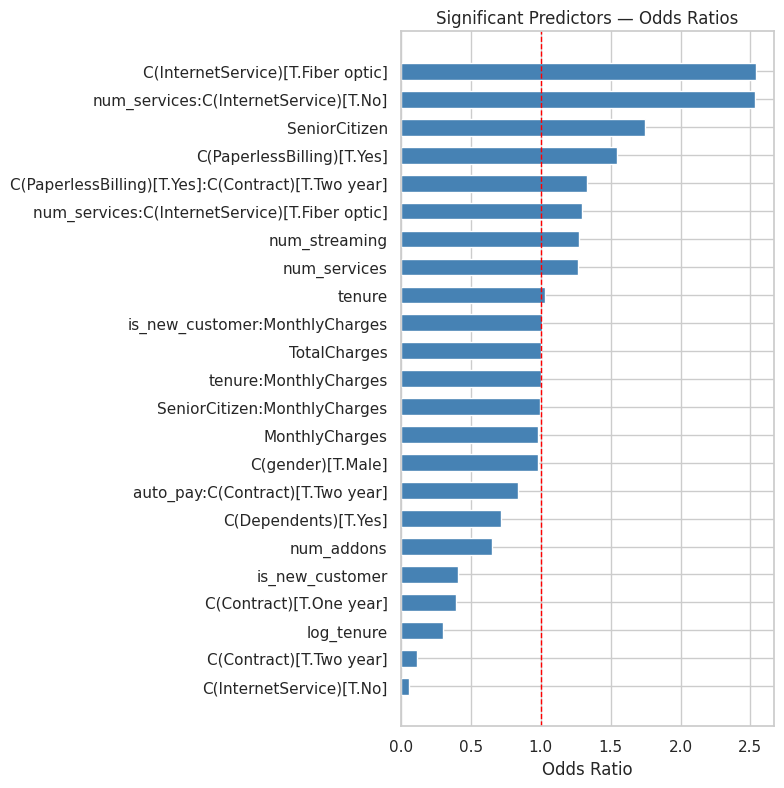

In [66]:
sig_or = odds_ratios[odds_ratios["significant"]].sort_values("OR")

fig, ax = plt.subplots(figsize=(8, max(4, len(sig_or) * 0.35)))
ax.barh(sig_or.index, sig_or["OR"], color="steelblue", height=0.6)
ax.axvline(1, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Odds Ratio")
ax.set_title("Significant Predictors — Odds Ratios")
plt.tight_layout()
plt.show()

## Average marginal effects

In [ ]:
mfx = logit_model.get_margeff(at="overall")
print(mfx.summary())

## Model diagnostics

In [ ]:
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

y_true = np.asarray(logit_model.model.endog, dtype=int)
y_prob = logit_model.predict()
y_pred = (y_prob >= 0.5).astype(int)

print(f"Pseudo R²: {logit_model.prsquared:.4f}")
print(f"AIC:       {logit_model.aic:.1f}")
print(f"BIC:       {logit_model.bic:.1f}")
print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}\n")
print(classification_report(y_true, y_pred, target_names=["No Churn", "Churn"]))

Pseudo R²: 0.4187
AIC:       368564.0
BIC:       368801.2
ROC-AUC:   0.9087

              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91    460377
       Churn       0.70      0.63      0.66    133817

    accuracy                           0.85    594194
   macro avg       0.80      0.78      0.78    594194
weighted avg       0.85      0.85      0.85    594194



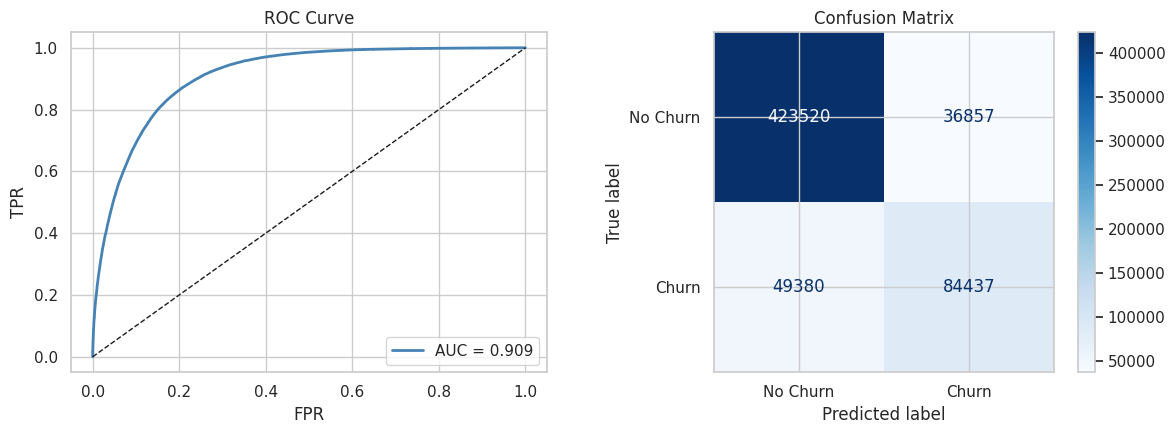

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {roc_auc_score(y_true, y_prob):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
axes[0].legend(loc="lower right")

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=["No Churn", "Churn"],
    cmap="Blues", ax=axes[1],
)
axes[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Variance Inflation Factor (multicollinearity)

In [ ]:
X_design = logit_model.model.exog
vif_data = pd.DataFrame({
    "feature": logit_model.model.exog_names,
    "VIF": [variance_inflation_factor(X_design, i) for i in range(X_design.shape[1])],
})
vif_data = vif_data[vif_data["feature"] != "Intercept"].sort_values("VIF", ascending=False)

print("Features with VIF > 5 (potential multicollinearity):\n")
high_vif = vif_data[vif_data["VIF"] > 5]
if len(high_vif):
    print(high_vif.to_string(index=False))
else:
    print("None — no concerning multicollinearity detected.")

print(f"\n--- Full VIF table ---")
vif_data

Features with VIF > 5 (potential multicollinearity):

                        feature     VIF
                   num_services 23.4329
log_tenure:avg_charge_per_month 22.7378
                     log_tenure 10.6143
                     num_addons 10.2680
           avg_charge_per_month  8.0224
                  num_streaming  5.2580

--- Full VIF table ---


,feature,VIF
10,num_services,23.4329
20,log_tenure:avg_charge_per_month,22.7378
13,log_tenure,10.6143
11,num_addons,10.2680
14,avg_charge_per_month,8.0224
12,num_streaming,5.2580
5,C(InternetService)[T.No],4.3353
7,C(Contract)[T.Two year],3.5639
15,charge_per_service,3.1682
16,is_new_customer,3.1458


## Likelihood Ratio test (full model vs null)

In [ ]:
null_model = smf.logit("churn ~ 1", data=train).fit(method="bfgs", disp=0)

lr_stat = -2 * (null_model.llf - logit_model.llf)
lr_df = logit_model.df_model - null_model.df_model
lr_pvalue = stats.chi2.sf(lr_stat, lr_df)

print(f"Log-Likelihood (null):  {null_model.llf:,.1f}")
print(f"Log-Likelihood (full):  {logit_model.llf:,.1f}")
print(f"LR statistic:           {lr_stat:,.1f}")
print(f"Degrees of freedom:     {lr_df}")
print(f"p-value:                {lr_pvalue:.2e}")
print(f"\nThe full model {'significantly' if lr_pvalue < 0.05 else 'does NOT significantly'} "
      f"improve over the null model.")

Log-Likelihood (null):  -316,955.2
Log-Likelihood (full):  -184,261.0
LR statistic:           265,388.5
Degrees of freedom:     20.0
p-value:                0.00e+00

The full model significantly improve over the null model.
